# Market Data

Download the observed AAPL trades used by the preprocessing workflow, then inspect the normalized project schema. Existing Parquet data is reused so repeated notebook runs do not make unnecessary external requests.

## Download the Data

In [1]:
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.data_preprocessing.market_data import save_alpaca_historical_data

PROJECT_ROOT = Path.cwd().resolve().parents[1]
market_path = PROJECT_ROOT / "data/research_data/market/data/aapl_2025-01-01_2025-12-31.parquet"

if not market_path.is_file():
    save_alpaca_historical_data(
        symbols=["AAPL"],
        start=datetime(2025, 1, 1, tzinfo=timezone.utc),
        end=datetime(2025, 12, 31, 23, 59, 59, 999999, tzinfo=timezone.utc),
        asset_class="stock",
        data_type="tick",
        output_path=market_path,
    )

market_data = pd.read_parquet(market_path)
market_data["timestamp"] = pd.to_datetime(market_data["timestamp"], utc=True)
market_path

PosixPath('/Users/kwonjunhyuk9/Documents/financial-machine-learning/data/research_data/market/data/aapl_2025-01-01_2025-12-31.parquet')

## Take a Quick Look at the Data Structure

In [2]:
market_data.head()

,timestamp,symbol,price,size
0,2025-01-02 13:45:58.902948+00:00,AAPL,250.00,20.0
1,2025-01-02 13:52:44.306521+00:00,AAPL,248.97,20.0
2,2025-01-02 13:52:44.306572+00:00,AAPL,248.98,20.0
3,2025-01-02 13:53:04.071807+00:00,AAPL,248.99,20.0
4,2025-01-02 13:53:04.071848+00:00,AAPL,249.00,20.0


In [3]:
market_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4464553 entries, 0 to 4464552
Data columns (total 4 columns):
 #   Column     Dtype              
---  ------     -----              
 0   timestamp  datetime64[us, UTC]
 1   symbol     str                
 2   price      float64            
 3   size       float64            
dtypes: datetime64[us, UTC](1), float64(2), str(1)
memory usage: 153.3 MB


In [4]:
market_data["symbol"].value_counts(dropna=False)

symbol
AAPL    4464553
Name: count, dtype: int64

In [5]:
market_data[["price", "size"]].describe()

,price,size
count,4.464553e+06,4.464553e+06
mean,2.302436e+02,8.061238e+01
std,2.825948e+01,1.542139e+02
min,1.686200e+02,1.000000e+00
25%,2.058800e+02,2.000000e+01
50%,2.286600e+02,1.000000e+02
75%,2.541400e+02,1.000000e+02
max,2.886100e+02,7.880000e+04


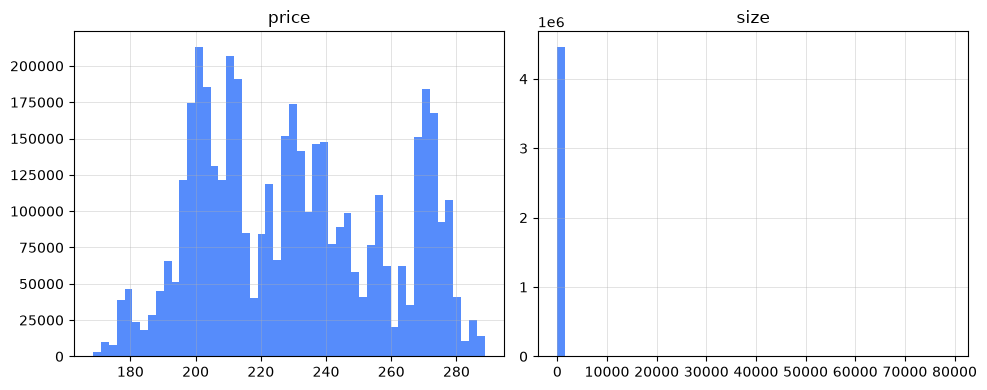

In [6]:
market_data[["price", "size"]].hist(bins=50, figsize=(10, 4))
plt.tight_layout()
plt.show()